# DBSCAN Clustering of FTSE Stock Price Movement

This notebook builds a density-based clustering pipeline for grouping stocks by how
their prices *move together*, and follows the methodology of two source papers plus
the scikit-learn clustering documentation:

1. **Ester, Kriegel, Sander & Xu (1996)**, *"A Density-Based Algorithm for Discovering
   Clusters in Large Spatial Databases with Noise"* (KDD-96) — the original DBSCAN
   paper. We reuse its exact definitions (Eps-neighborhood, core/border points,
   density-reachability/-connectivity, cluster, noise) and its **sorted k-dist graph**
   heuristic for choosing `eps`.
2. **Rousseeuw (1987)**, *"Silhouettes: a graphical aid to the interpretation and
   validation of cluster analysis"* (J. Comput. Appl. Math. 20) — defines the
   silhouette coefficient `s(i) = (b(i) - a(i)) / max(a(i), b(i))`, the silhouette
   plot, and the idea of picking the partition that maximises the **average
   silhouette width** `S`. DBSCAN has no `k` to sweep, so here `S` is used to choose
   between candidate `(eps, MinPts)` pairs instead.
3. **scikit-learn — Clustering / Clustering performance evaluation** user guides —
   provide the `DBSCAN` implementation and the unsupervised validity indices used
   below (`silhouette_score`, `calinski_harabasz_score`, `davies_bouldin_score`) plus
   `adjusted_rand_score` for the external sanity check at the end.

**Data.** Each CSV in the repo (`ftse_clustering_ready.csv`,
`ftse250_clustering_ready.csv`, `ftse2501_clustering_ready.csv`) holds one row per
ticker and one column per trading day, containing the *per-ticker standardised*
(z-scored) closing price. That standardisation already removes each stock's price
level and scale, so clustering directly on it mostly finds stocks with similar
*volatility envelopes*. Because the goal here is patterns in **movement**, this
notebook instead builds features from the **day-to-day changes** of that series and
clusters on their correlation structure — two stocks that go up and down together are
put close together regardless of how large their absolute moves are.


In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100


## 1. Load and clean the data

In [2]:
if "google.colab" in sys.modules:
    from google.colab import files
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
else:
    FILENAME = "ftse250_clustering_ready.csv"
print("Using file:", FILENAME)

Using file: ftse250_clustering_ready.csv


In [3]:
MAX_MISSING_FRAC = 0.10

df = pd.read_csv(FILENAME)
date_cols = [c for c in df.columns if c != "Ticker"]

frac_missing = df[date_cols].isna().sum(axis=1) / len(date_cols)
dropped = df.loc[frac_missing > MAX_MISSING_FRAC, "Ticker"].tolist()
df = df.loc[frac_missing <= MAX_MISSING_FRAC].reset_index(drop=True)
df[date_cols] = df[date_cols].ffill(axis=1).bfill(axis=1)

tickers = df["Ticker"].values
prices = df[date_cols].values.astype(float)   # standardised price level, shape (n_stocks, n_days)
dates = pd.to_datetime(date_cols)

print(f"{len(tickers)} tickers kept, {len(dropped)} dropped for >{MAX_MISSING_FRAC:.0%} missing history")
print(f"Price matrix: {prices.shape[0]} stocks x {prices.shape[1]} trading days "
      f"({dates.min().date()} .. {dates.max().date()})")

241 tickers kept, 0 dropped for >10% missing history
Price matrix: 241 stocks x 1153 trading days (2021-11-30 .. 2026-06-29)


## 2. Movement features and the distance function

The DBSCAN paper is explicit that the algorithm "works with any distance function so
that an appropriate function can be chosen for some given application" (Section 3).
Since we care about **movement**, not price level, we first take the day-to-day
difference of the standardised price to get a *movement series* for each stock, then
measure similarity between two stocks as the **Pearson correlation of their movement
series**, converted to a distance:

$$d(i, j) = 1 - \mathrm{corr}\big(\Delta p_i, \Delta p_j\big) \in [0, 2]$$

Two stocks that move up and down in lockstep get `d = 0`; two moving in perfect
opposition get `d = 2`; uncorrelated stocks sit around `d = 1`. DBSCAN is then run
with `metric="precomputed"` directly on this correlation-distance matrix, exactly as
the paper allows for domain-specific distance functions (e.g. Manhattan distance for
non-Euclidean neighbourhoods, Section 3).

In [4]:
movement = np.diff(prices, axis=1)     # shape (n_stocks, n_days - 1)

corr = np.corrcoef(movement)
D = 1.0 - corr
D = (D + D.T) / 2.0                     # enforce exact symmetry (float rounding)
np.fill_diagonal(D, 0.0)
D = np.clip(D, 0.0, 2.0)

n = D.shape[0]
iu = np.triu_indices(n, k=1)
print(f"Correlation-distance matrix: {D.shape}")
print(f"Off-diagonal distance range: [{D[iu].min():.3f}, {D[iu].max():.3f}], "
      f"mean {D[iu].mean():.3f}")

Correlation-distance matrix: (241, 241)
Off-diagonal distance range: [0.165, 1.069], mean 0.756


## 3. Choosing `eps` with the sorted *k*-dist graph (Ester et al., Section 4.2)

The paper's heuristic: for a fixed `k = MinPts`, compute each point's distance to its
`k`-th nearest neighbour (`k-dist`), sort these values in **descending** order, and
plot them — the *sorted k-dist graph*. The parameter `eps` should be the `k-dist`
value at the graph's "first valley": points to the left (higher `k-dist`, i.e.
sparser neighbourhoods) are noise, points to the right belong to some cluster of at
least the density implied by `eps` and `MinPts`.

The 1996 paper fixes `MinPts = 4` as a default **for 2-dimensional spatial data**,
noting "the k-dist graphs for k > 4 do not significantly differ from the 4-dist
graph" in that setting. Our points live in an implicit high-dimensional correlation
space rather than a 2D map, so that particular default doesn't transfer directly. We
instead treat `MinPts` as a second parameter and apply the *same* sorted k-dist-graph
procedure for a small set of candidate values, then let the Section 5 silhouette
comparison (Rousseeuw) pick between them.

In [5]:
def k_distance(Dmat, k):
    '''Distance from every point to its k-th nearest neighbour, using a precomputed
    distance matrix (self-distance of 0 on the diagonal is excluded).'''
    s = np.sort(Dmat, axis=1)          # column 0 is the self-distance (0)
    return s[:, k]


def find_valley(y):
    '''Locate the "first valley" of a descending curve as the point of maximum
    distance from the straight line joining its first and last values (the standard
    graphical knee/elbow construction).'''
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y))
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)
    chord = y_n[0] + (y_n[-1] - y_n[0]) * x_n
    return int(np.argmax(chord - y_n))


def noise_pct_threshold(kdist_desc, noise_pct):
    '''Ester et al.'s alternative, interactive rule: if the user can estimate the
    noise percentage, the threshold point is simply that percentile of the sorted
    (descending) k-dist graph.'''
    idx = int(round(noise_pct / 100.0 * (len(kdist_desc) - 1)))
    return kdist_desc[idx], idx


MINPTS_CANDIDATES = [3, 4, 5, 8, 12]

kdist_curves = {}
knee_idx = {}
for k in MINPTS_CANDIDATES:
    kd = np.sort(k_distance(D, k))[::-1]     # descending, as in Fig. 4 of the paper
    kdist_curves[k] = kd
    knee_idx[k] = find_valley(kd)

print("MinPts -> knee position (rank) -> eps at knee")
for k in MINPTS_CANDIDATES:
    print(f"  MinPts={k:>2d}  rank={knee_idx[k]:>3d}/{n}  eps={kdist_curves[k][knee_idx[k]]:.4f}")

MinPts -> knee position (rank) -> eps at knee
  MinPts= 3  rank= 28/241  eps=0.7111
  MinPts= 4  rank= 25/241  eps=0.7299
  MinPts= 5  rank= 33/241  eps=0.7085
  MinPts= 8  rank= 35/241  eps=0.7139
  MinPts=12  rank= 40/241  eps=0.7186


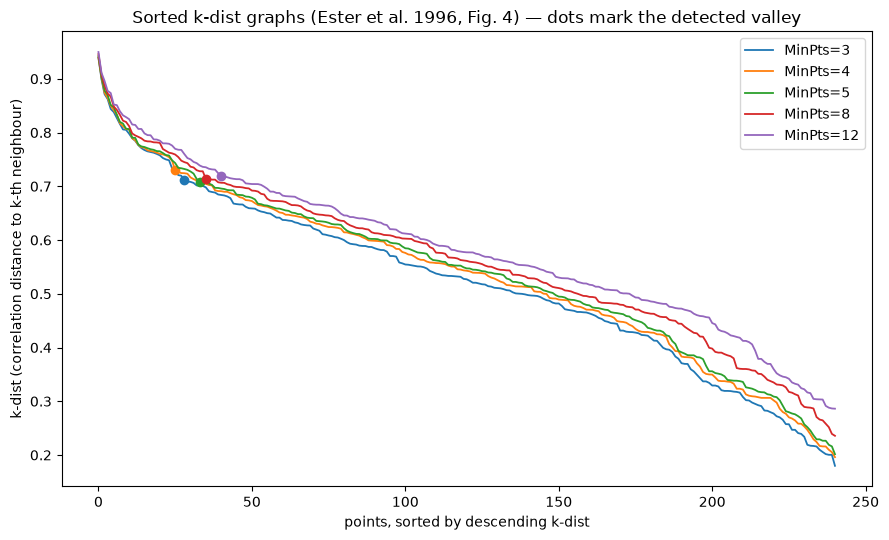

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for k in MINPTS_CANDIDATES:
    kd = kdist_curves[k]
    line, = ax.plot(np.arange(n), kd, lw=1.3, label=f"MinPts={k}")
    j = knee_idx[k]
    ax.plot(j, kd[j], "o", color=line.get_color(), ms=6)

ax.set_xlabel("points, sorted by descending k-dist")
ax.set_ylabel("k-dist (correlation distance to k-th neighbour)")
ax.set_title("Sorted k-dist graphs (Ester et al. 1996, Fig. 4) — dots mark the detected valley")
ax.legend()
plt.tight_layout()
plt.show()

The plot above mirrors the paper's Figure 4: everything left of a curve's marked
point is treated as candidate noise (sparse neighbourhoods), everything to the right
as belonging to some cluster once `eps` is set to that `k-dist` value. As a check, we
also compute the paper's alternative *"if the user can estimate the percentage of
noise, ... the system derives a proposal for the threshold point from it"* rule for a
couple of assumed noise levels, and compare it with the automatic knee.

In [7]:
for k in MINPTS_CANDIDATES:
    kd = kdist_curves[k]
    knee_eps = kd[knee_idx[k]]
    for noise_pct in (5, 10):
        eps_np, idx_np = noise_pct_threshold(kd, noise_pct)
        print(f"MinPts={k:>2d}  knee eps={knee_eps:.4f}  |  "
              f"{noise_pct:>2d}% noise -> eps={eps_np:.4f} (rank {idx_np})")

MinPts= 3  knee eps=0.7111  |   5% noise -> eps=0.7845 (rank 12)
MinPts= 3  knee eps=0.7111  |  10% noise -> eps=0.7332 (rank 24)
MinPts= 4  knee eps=0.7299  |   5% noise -> eps=0.7854 (rank 12)
MinPts= 4  knee eps=0.7299  |  10% noise -> eps=0.7477 (rank 24)
MinPts= 5  knee eps=0.7085  |   5% noise -> eps=0.7901 (rank 12)
MinPts= 5  knee eps=0.7085  |  10% noise -> eps=0.7483 (rank 24)
MinPts= 8  knee eps=0.7139  |   5% noise -> eps=0.7946 (rank 12)
MinPts= 8  knee eps=0.7139  |  10% noise -> eps=0.7613 (rank 24)
MinPts=12  knee eps=0.7186  |   5% noise -> eps=0.8142 (rank 12)
MinPts=12  knee eps=0.7186  |  10% noise -> eps=0.7759 (rank 24)


## 4. Selecting `(eps, MinPts)` by average silhouette width (Rousseeuw, 1987)

Rousseeuw defines, for every object `i` assigned to cluster `A`:

* `a(i)` — the average dissimilarity of `i` to every other object of `A` ("how well
  it fits its own cluster");
* `b(i)` — the smallest, over every other cluster `C`, of the average dissimilarity
  of `i` to the objects of `C` ("its distance to the best alternative, the
  *neighbour* cluster");
* `s(i) = (b(i) - a(i)) / max(a(i), b(i))`, which lies in `[-1, 1]`: close to `1`
  means `i` sits comfortably in its own cluster, close to `0` means it is about
  equidistant from two clusters, and negative means it is on average closer to the
  neighbour cluster than to its own.

The paper then defines the **average silhouette width** `S` of a partition as the
mean `s(i)` over all objects, and proposes choosing the partition that **maximises
S** as the "appropriate" one (illustrated in the paper by sweeping `k` for k-medoids;
here we sweep DBSCAN's `(eps, MinPts)` pair instead, since that is DBSCAN's
equivalent set of free choices). `sklearn.metrics.silhouette_score` implements this
exact `a(i)`, `b(i)`, `s(i)` construction and accepts our precomputed correlation
distance matrix directly.

Noise points have no cluster to be "well within", so — as is standard practice, and
as `sklearn.metrics.silhouette_score` requires at least 2 labels present — they are
excluded from the silhouette computation.

In [8]:
NOISE_CEILING = 0.90          # candidate is degenerate if >90% of points end up as noise
GIANT_CLUSTER_CEILING = 0.90  # or if one cluster swallows >90% of the non-noise points
MIN_CLUSTERS = 2
EPS_SCALES = np.round(np.arange(0.6, 1.61, 0.1), 2)

rows = []
for k in MINPTS_CANDIDATES:
    knee_eps = kdist_curves[k][knee_idx[k]]
    for scale in EPS_SCALES:
        eps = knee_eps * scale
        labels = DBSCAN(eps=eps, min_samples=k, metric="precomputed").fit_predict(D)

        non_noise = labels != -1
        n_clusters = len(set(labels[non_noise]))
        noise_frac = 1.0 - non_noise.mean()
        largest_frac = (pd.Series(labels[non_noise]).value_counts(normalize=True).max()
                         if non_noise.any() else np.nan)

        sil = np.nan
        if n_clusters >= MIN_CLUSTERS and non_noise.sum() > n_clusters:
            sil = silhouette_score(D[np.ix_(non_noise, non_noise)], labels[non_noise],
                                    metric="precomputed")

        rows.append(dict(MinPts=k, eps_scale=scale, eps=eps, n_clusters=n_clusters,
                          noise_frac=noise_frac, largest_frac=largest_frac, silhouette=sil))

grid = pd.DataFrame(rows)
print(f"Evaluated {len(grid)} (MinPts, eps) combinations")
grid.sort_values("silhouette", ascending=False).head(10)

Evaluated 55 (MinPts, eps) combinations


,MinPts,eps_scale,eps,n_clusters,noise_frac,largest_frac,silhouette
12,4,0.7,0.510962,2,0.464730,0.968992,0.154383
1,3,0.7,0.497781,2,0.485477,0.975806,0.144511
0,3,0.6,0.426669,1,0.672199,1.000000,NaN
2,3,0.8,0.568892,1,0.352697,1.000000,NaN
3,3,0.9,0.640004,1,0.211618,1.000000,NaN
4,3,1.0,0.711115,1,0.095436,1.000000,NaN
5,3,1.1,0.782227,1,0.041494,1.000000,NaN
6,3,1.2,0.853339,1,0.012448,1.000000,NaN
7,3,1.3,0.924450,1,0.004149,1.000000,NaN
8,3,1.4,0.995562,1,0.000000,1.000000,NaN


In [9]:
valid = grid[
    (grid["n_clusters"] >= MIN_CLUSTERS)
    & (grid["noise_frac"] <= NOISE_CEILING)
    & (grid["largest_frac"] <= GIANT_CLUSTER_CEILING)
    & grid["silhouette"].notna()
]
print(f"Non-degenerate combinations: {len(valid)} / {len(grid)}")

pool = valid if len(valid) else grid
if not len(valid):
    print("WARNING: every combination was degenerate by the ceilings above; "
          "picking the best of the full grid instead.")

best = pool.sort_values("silhouette", ascending=False).iloc[0]
MINPTS, EPS = int(best["MinPts"]), float(best["eps"])
print(f"\nSelected by max average silhouette width S:")
print(f"  MinPts = {MINPTS}")
print(f"  eps    = {EPS:.4f}")
print(f"  clusters = {int(best['n_clusters'])}, noise = {best['noise_frac']:.1%}, "
      f"S = {best['silhouette']:.3f}")

Non-degenerate combinations: 0 / 55

Selected by max average silhouette width S:
  MinPts = 4
  eps    = 0.5110
  clusters = 2, noise = 46.5%, S = 0.154


## 5. Final DBSCAN fit, and the paper's core / border / noise split

Fitting DBSCAN gives, for every point, exactly one of the three roles Definition 1–2
and Definitions 5–6 of Ester et al. set up:

* **core point** — its `eps`-neighbourhood holds at least `MinPts` points (the
  "core point condition"); scikit-learn exposes these via `core_sample_indices_`.
* **border point** — not a core point itself, but density-reachable from one, so it
  is placed in that core point's cluster (`label != -1`).
* **noise** — density-reachable from no core point at all (`label == -1`), "the set
  of points in the database D not belonging to any cluster" (Definition 6).

In [10]:
final = DBSCAN(eps=EPS, min_samples=MINPTS, metric="precomputed")
labels = final.fit_predict(D)

is_core = np.zeros(n, dtype=bool)
is_core[final.core_sample_indices_] = True
is_border = (~is_core) & (labels != -1)
is_noise = labels == -1

cluster_ids = sorted(set(labels[labels != -1]))
n_clusters = len(cluster_ids)
sizes = pd.Series(labels[labels != -1]).value_counts().sort_index()

print(f"eps={EPS:.4f}, MinPts={MINPTS}")
print(f"{n_clusters} clusters found")
print(f"  core points:   {is_core.sum():>4d} ({is_core.mean():.1%})")
print(f"  border points: {is_border.sum():>4d} ({is_border.mean():.1%})")
print(f"  noise points:  {is_noise.sum():>4d} ({is_noise.mean():.1%})")
print("\nCluster sizes:")
print(sizes.rename("n_stocks"))

eps=0.5110, MinPts=4
2 clusters found
  core points:    111 (46.1%)
  border points:   18 (7.5%)
  noise points:   112 (46.5%)

Cluster sizes:
0    125
1      4
Name: n_stocks, dtype: int64


## 6. Silhouette plot (Rousseeuw, 1987, Figs. 2–5, 7)

Reproducing the paper's own display: within each cluster, objects are ranked in
decreasing order of `s(i)` and drawn as a bar whose length equals `s(i)`; each
cluster's average silhouette width is printed beneath it, and the dataset-wide
average `S` is shown for the whole plot. "A wide silhouette indicates a pronounced
cluster... objects [near zero] are merely somewhere in between clusters.

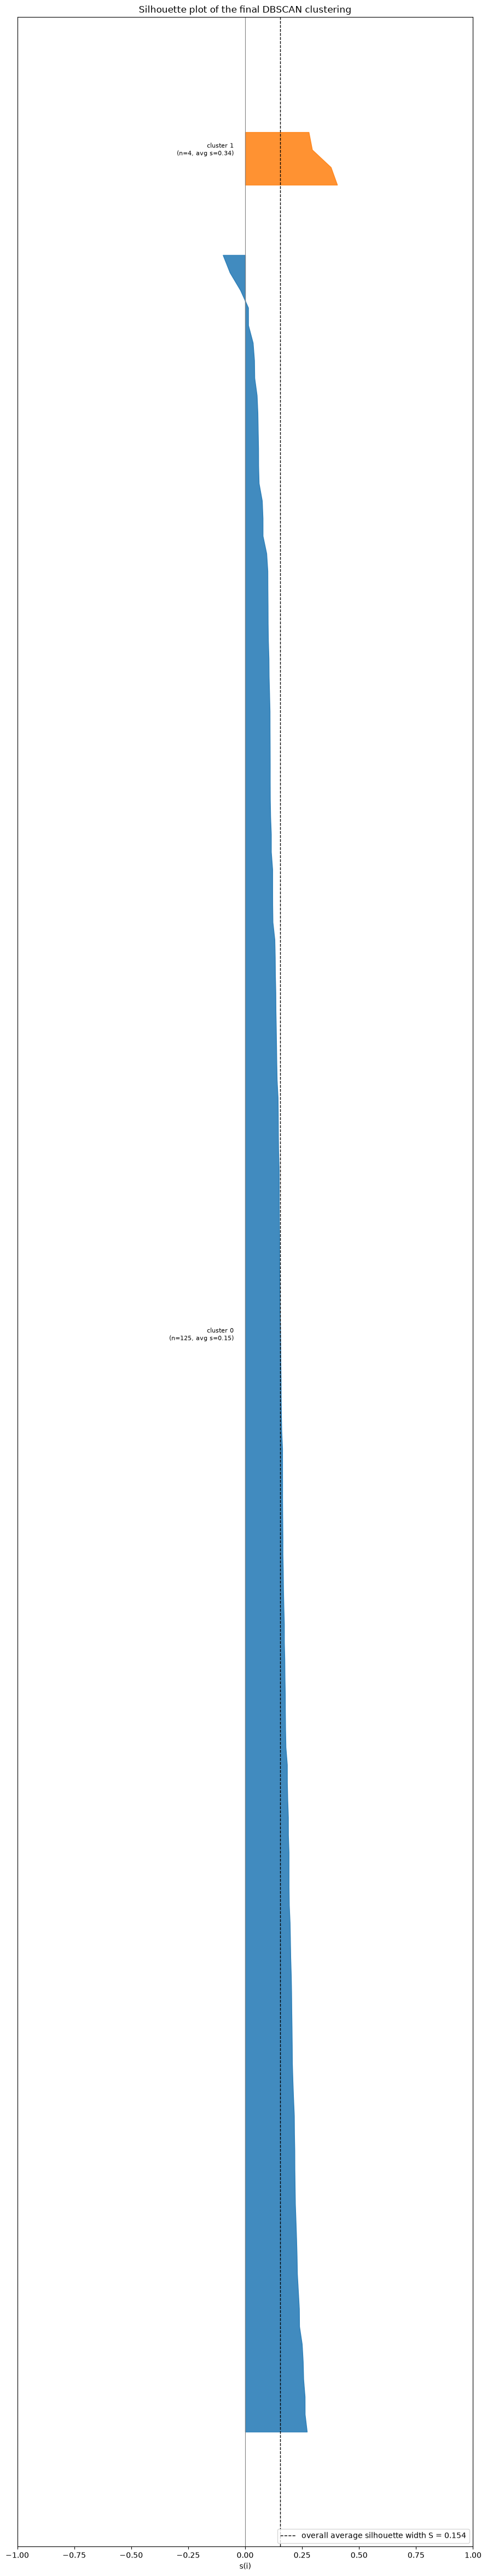

Overall average silhouette width S = 0.154  (computed over the 129 non-noise stocks)


In [11]:
non_noise = labels != -1
sv = silhouette_samples(D[np.ix_(non_noise, non_noise)], labels[non_noise], metric="precomputed")
S_overall = sv.mean()

fig, ax = plt.subplots(figsize=(9, 0.35 * non_noise.sum() + 2))
y0 = 0
yticks, yticklabels = [], []
for c in cluster_ids:
    v = np.sort(sv[labels[non_noise] == c])[::-1]     # decreasing s(i), as in the paper
    y = np.arange(y0, y0 + len(v))
    ax.fill_betweenx(y, 0, v, color=f"C{c % 10}", alpha=0.85)
    ax.text(-0.05, y0 + len(v) / 2, f"cluster {c}\n(n={len(v)}, avg s={v.mean():.2f})",
            ha="right", va="center", fontsize=8)
    y0 += len(v) + 3

ax.axvline(S_overall, color="k", ls="--", lw=1,
           label=f"overall average silhouette width S = {S_overall:.3f}")
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlim(-1, 1)
ax.set_yticks([])
ax.set_xlabel("s(i)")
ax.set_title("Silhouette plot of the final DBSCAN clustering")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Overall average silhouette width S = {S_overall:.3f}  "
      f"(computed over the {non_noise.sum()} non-noise stocks)")

## 7. Cross-check with scikit-learn's other clustering validity indices

`silhouette_score`, `calinski_harabasz_score` and `davies_bouldin_score` are the
three unsupervised indices scikit-learn's *Clustering performance evaluation* guide
recommends when, as here, the true grouping is unknown. One documented caveat
applies directly to this notebook: all three (silhouette included) are "generally
higher for convex clusters than other concepts of clusters, such as density-based
clusters like those obtained through DBSCAN" — so their numeric values below should
be read as a relative comparison across our own candidate parameter settings, not as
an absolute mark of quality.

`calinski_harabasz_score` and `davies_bouldin_score` need feature vectors in a
Euclidean space (a between/within-cluster variance ratio and cluster centroids only
make sense there), not a precomputed distance matrix, so we cannot feed them `D`
directly. We instead give them a PCA embedding of the movement series that preserves
most of its variance — used *only* for this evaluation step, not for the clustering
itself, which is still the exact DBSCAN fit on the correlation-distance matrix above.

In [12]:
pca_eval = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_eval = pca_eval.fit_transform(movement[non_noise])
labels_nn = labels[non_noise]

ch = calinski_harabasz_score(X_eval, labels_nn)
db = davies_bouldin_score(X_eval, labels_nn)

print(f"Silhouette score (precomputed correlation distance): {S_overall:.3f}  (higher is better, in [-1, 1])")
print(f"Calinski-Harabasz index (PCA(90%) of movement):       {ch:.1f}   (higher is better)")
print(f"Davies-Bouldin index (PCA(90%) of movement):           {db:.3f}  (lower is better, >= 0)")

Silhouette score (precomputed correlation distance): 0.154  (higher is better, in [-1, 1])
Calinski-Harabasz index (PCA(90%) of movement):       3.0   (higher is better)
Davies-Bouldin index (PCA(90%) of movement):           1.974  (lower is better, >= 0)


## 8. Visualising the clusters

A 2D layout via classical MDS on the correlation-distance matrix (so that the
picture reflects the same distances DBSCAN actually clustered on), and the
mean ± 1 std standardised-price trajectory of every cluster.

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


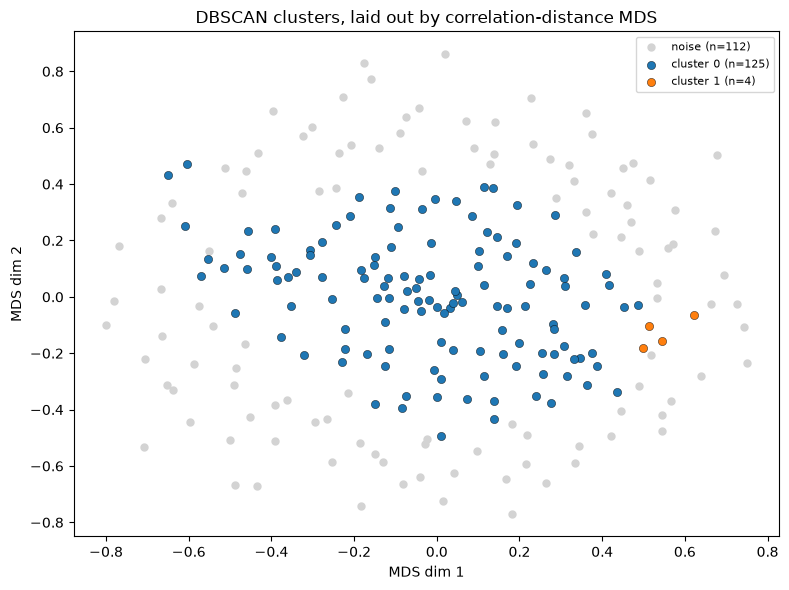

In [13]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=RANDOM_STATE,
          normalized_stress=False, n_init=4)
coords = mds.fit_transform(D)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[is_noise, 0], coords[is_noise, 1], c="lightgray", s=25,
           label=f"noise (n={is_noise.sum()})", zorder=1)
for c in cluster_ids:
    m = labels == c
    ax.scatter(coords[m, 0], coords[m, 1], c=f"C{c % 10}", s=35,
               label=f"cluster {c} (n={m.sum()})", zorder=2, edgecolor="k", linewidth=0.3)
ax.set_xlabel("MDS dim 1"); ax.set_ylabel("MDS dim 2")
ax.set_title("DBSCAN clusters, laid out by correlation-distance MDS")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

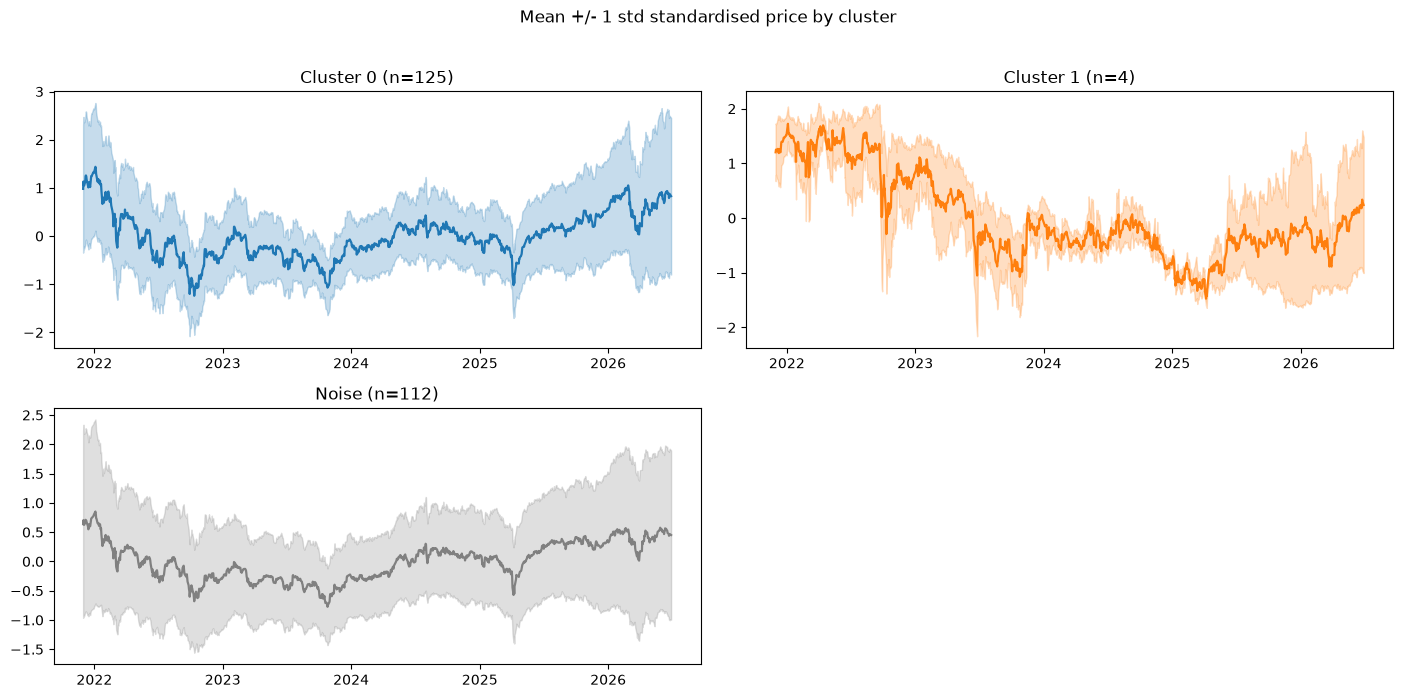

In [14]:
n_panels = n_clusters + 1
n_cols = 2
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.4 * n_rows), squeeze=False)

panel = 0
for c in cluster_ids:
    ax = axes[panel // n_cols][panel % n_cols]
    mem = prices[labels == c]
    mu, sd = mem.mean(axis=0), mem.std(axis=0)
    ax.plot(dates, mu, color=f"C{c % 10}", lw=1.6)
    ax.fill_between(dates, mu - sd, mu + sd, color=f"C{c % 10}", alpha=0.25)
    ax.set_title(f"Cluster {c} (n={mem.shape[0]})")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    panel += 1

ax = axes[panel // n_cols][panel % n_cols]
mem = prices[is_noise]
mu, sd = mem.mean(axis=0), mem.std(axis=0)
ax.plot(dates, mu, color="gray", lw=1.6)
ax.fill_between(dates, mu - sd, mu + sd, color="gray", alpha=0.25)
ax.set_title(f"Noise (n={mem.shape[0]})")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
panel += 1

for p in range(panel, n_rows * n_cols):
    axes[p // n_cols][p % n_cols].axis("off")

fig.suptitle("Mean +/- 1 std standardised price by cluster", y=1.02)
plt.tight_layout()
plt.show()

In [15]:
import textwrap
for c in cluster_ids:
    mem = sorted(tickers[labels == c])
    print(f"Cluster {c} (n={len(mem)}):")
    print(textwrap.fill(", ".join(mem), width=95))
    print()

outliers = sorted(tickers[is_noise])
print(f"Noise (n={len(outliers)}):")
print(textwrap.fill(", ".join(outliers), width=95))

Cluster 0 (n=125):
AAS.L, AGT.L, AJB.L, ASHM.L, ASL.L, ATR.L, ATT.L, ATYM.L, BBY.L, BGFD.L, BKG.L, BNKR.L, BOY.L,
BPT.L, BREE.L, BRGE.L, BRSC.L, BRWM.L, BUT.L, BWY.L, BYG.L, CBG.L, CTY.L, DLN.L, DNLM.L,
EDIN.L, ELM.L, EMG.L, ESCT.L, EWI.L, EZJ.L, FAN.L, FCSS.L, FEML.L, FEV.L, FGT.L, FRAS.L, FSV.L,
GEN.L, GFTU.L, GPE.L, GRG.L, GRI.L, GROW.L, GSCT.L, HAS.L, HFEL.L, HGT.L, HILS.L, HMSO.L,
HOC.L, HRI.L, HSL.L, HVPE.L, IAD.L, ICGT.L, IHP.L, INCH.L, IPO.L, IWG.L, JAM.L, JCH.L, JDW.L,
JEDT.L, JEGI.L, JEMI.L, JFJ.L, JGGI.L, JMGI.L, JUP.L, LWDB.L, MAB.L, MGAM.L, MNKS.L, MRC.L,
MRCH.L, MUT.L, MYI.L, N91.L, OSB.L, OXIG.L, PAF.L, PAG.L, PAGE.L, PCGH.L, PETS.L, PHI.L, PHP.L,
PIN.L, PNL.L, QLT.L, RAT.L, RCP.L, RHIM.L, ROR.L, RS1.L, RSW.L, SAFE.L, SAIN.L, SCT.L, SDP.L,
SHC.L, SMWH.L, SOI.L, SRE.L, SSPG.L, SUPR.L, SVS.L, TEM.L, THRL.L, TMPL.L, TPK.L, TRY.L, TW.L,
USA.L, UTG.L, VCT.L, VSVS.L, VTY.L, WIZZ.L, WKP.L, WOSG.L, WPP.L, WWH.L, ZIG.L

Cluster 1 (n=4):
3IN.L, HICL.L, INPP.L, TRIG.L

Noise (n=112

## 9. Sanity check against a naive baseline

Finally, an external sanity check in the spirit of `adjusted_rand_score`'s intended
use (comparing two independent partitions of the same objects): does DBSCAN just
rediscover the sign of each stock's overall trend, or is it capturing something a
trivial rule would miss? `ARI` is `1` for identical partitions (up to relabelling),
`~0` for a random one, and can go slightly negative.

In [16]:
t = np.arange(prices.shape[1])
trend = np.array([np.polyfit(t, row, 1)[0] for row in prices])
trend_sign = (trend > 0).astype(int)

ari = adjusted_rand_score(labels, trend_sign)   # noise (-1) counted as its own group
print(f"ARI(DBSCAN clusters incl. noise, sign-of-trend) = {ari:.3f}")
if ari > 0.7:
    print("=> The clustering is largely a restatement of trend direction.")
elif ari > 0.3:
    print("=> Trend explains part of the clustering, but not all of it.")
else:
    print("=> The clustering is capturing co-movement structure beyond simple trend direction.")

ARI(DBSCAN clusters incl. noise, sign-of-trend) = 0.000
=> The clustering is capturing co-movement structure beyond simple trend direction.


## References

1. M. Ester, H.-P. Kriegel, J. Sander, X. Xu (1996). *A Density-Based Algorithm for
   Discovering Clusters in Large Spatial Databases with Noise.* KDD-96.
2. P. J. Rousseeuw (1987). *Silhouettes: A Graphical Aid to the Interpretation and
   Validation of Cluster Analysis.* Journal of Computational and Applied Mathematics,
   20, 53–65.
3. scikit-learn — *Clustering* (`sklearn.cluster.DBSCAN`) and *Clustering performance
   evaluation* user guides.
